In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd


creatives = list(Path("data/BetterMe Creatives").glob("*"))
metadata = pd.read_csv("data/[Right + Local Path] BetterMe Creatives_clean+text.csv", index_col=0)


images = [creative for creative in creatives if creative.suffix == ".jpg" and int(creative.stem) in metadata.index]
videos = [creative for creative in creatives if creative.suffix == ".mp4" and int(creative.stem) in metadata.index]

Percentage of images:  0.27631578947368424
	Then number of images in a test set:  4
	Then number of images in a train set:  11


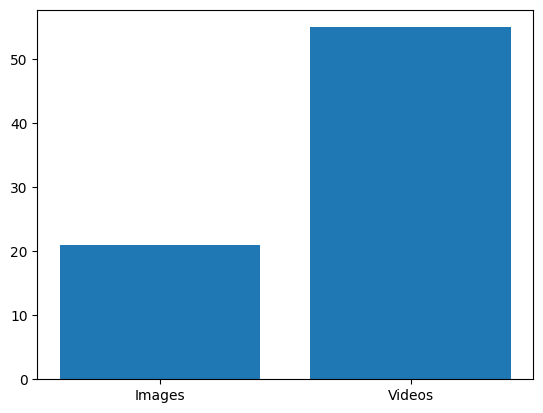

In [6]:
plt.bar(
    ["Images", "Videos"],
    height=[len(images), len(videos)]
)

image_percentage = len(images) / (len(images) + len(videos))
test_set_size = 15
test_image_number = int(image_percentage * test_set_size)
test_video_number = test_set_size - test_image_number

print("Percentage of images: ", image_percentage)
print("\tThen number of images in a test set: ", test_image_number)
print("\tThen number of images in a train set: ", test_video_number)

In [7]:
import numpy as np
import json
np.random.seed(0)


test_images = np.random.choice(images, test_image_number, replace=False)
test_videos = np.random.choice(videos, test_video_number, replace=False)

test_objects = [*test_images.tolist(), *test_videos.tolist()]

with open("test_objects.json", "w") as f:
	json.dump(test_objects, f, default=lambda x: x.as_posix(), indent=4)